# IC diagnosis — the four-arm analyst board

**Board:** `reports/hk`, 11 analysts × 4 text arms, 2016-01 → 2026-06, Haiku, 5,528 records.

An information coefficient is one number over ~125 observations. This takes it apart along
the axes a point estimate collapses: **arm**, **instrument**, **the joint distribution**,
**time**, and — last, because it is the part most likely to be over-trusted — **the
t-statistic itself**.

Two thresholds recur and they are not the same thing. The **IC needed for t = 2** at this
sample size is about **0.18** — statistical visibility. The **IC needed for an information
ratio of 1.0** at ~12 bets a year is **0.289** — economic usefulness. A driver can clear the
first and fail the second, and most of this panel does.

Everything is offline over saved runs, $0, and must never inform a prompt
(`docs/analyst-layer.md` §6).

In [1]:
import sys, os, glob, math, warnings
warnings.filterwarnings("ignore")
sys.path.insert(0, os.path.abspath("..")); sys.path.insert(0, ".")
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import _viz as V; V.use_style()
from src.layered.evaluation.runs import load_run
from src.layered.evaluation import ic_diagnostics as D, attribution as A
from src.layered.evaluation.trade_pnl import forward_yield_change
from src.data.equity_local import load_any_bundle

BOARD, ARM = "../reports/hk", "anon_cue"
ARMS = ["none", "anon_cue", "anon_full", "plain"]
LABEL = {"none":"none\n(numbers only)","anon_cue":"anon_cue\n(driver extract)",
         "anon_full":"anon_full\n(whole statement)","plain":"plain\n(LEAK ARM)"}
RELEASE = {"inflation","labor_tightness"}
runs={}
for f in sorted(glob.glob(f"{BOARD}/*.jsonl")):
    st=os.path.basename(f)[:-6]
    for a in ARMS:
        if st.endswith("_"+a): runs[(st[:-(len(a)+1)],a)]=load_run(f); break
DRIVERS=sorted({d for d,_ in runs})
rows=[]
for (d,a),r in runs.items():
    al=D.align(r.signed.dropna(), r.level.dropna()); n,ic,t=D.rank_ic(al["s"],al["y"])
    rows.append({"driver":d,"arm":a,"n":n,"ic":ic,"t":t})
IC=pd.DataFrame(rows)
print(f"{len(runs)} legs · {len(DRIVERS)} analysts")

44 legs · 11 analysts


## 1 — Ranked IC per analyst, one arm at a time

Four separate figures deliberately. The arms are not equally interpretable —
`positioning`'s `anon_cue` **is** its `none` arm because its excerpt coverage is zero, and
`plain` is a leak probe whose IC is not an analyst result — so each is read on its own
before any comparison.

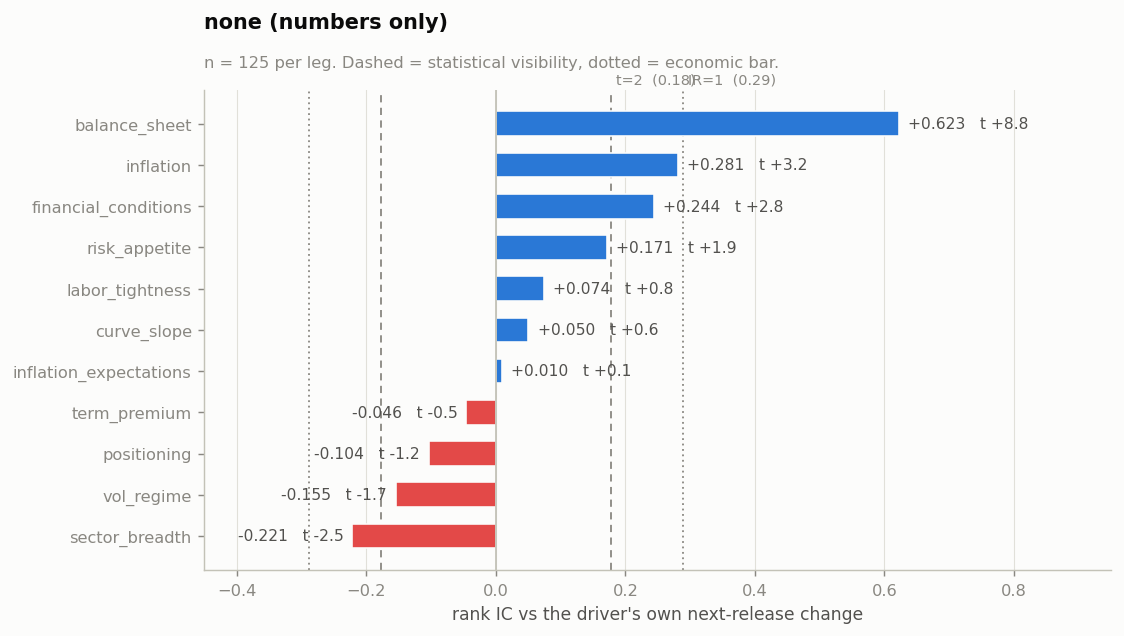

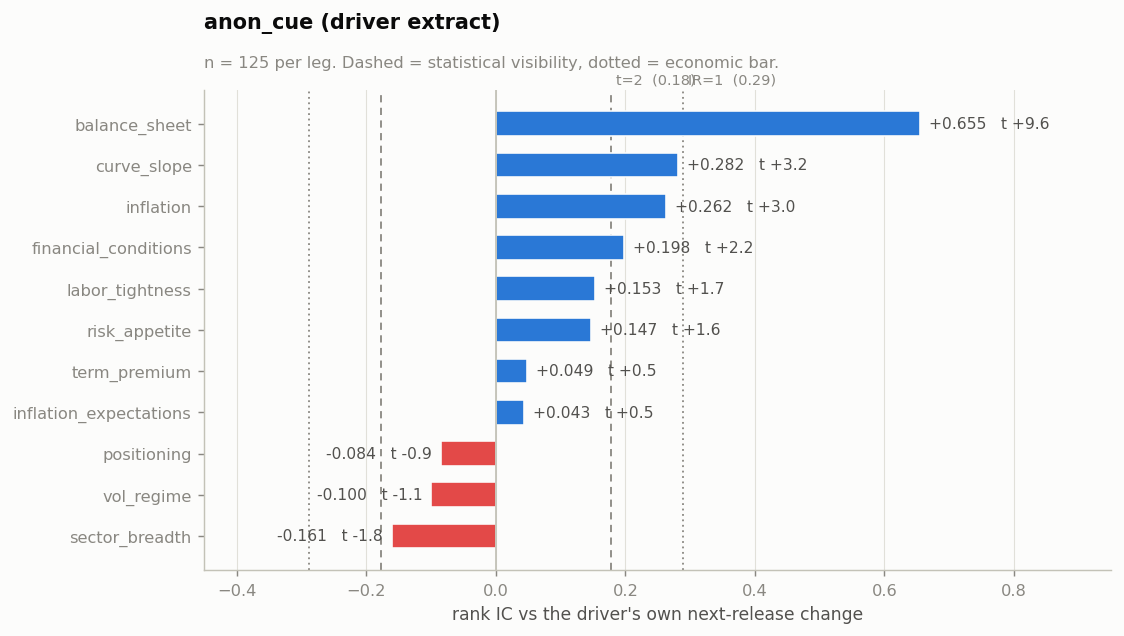

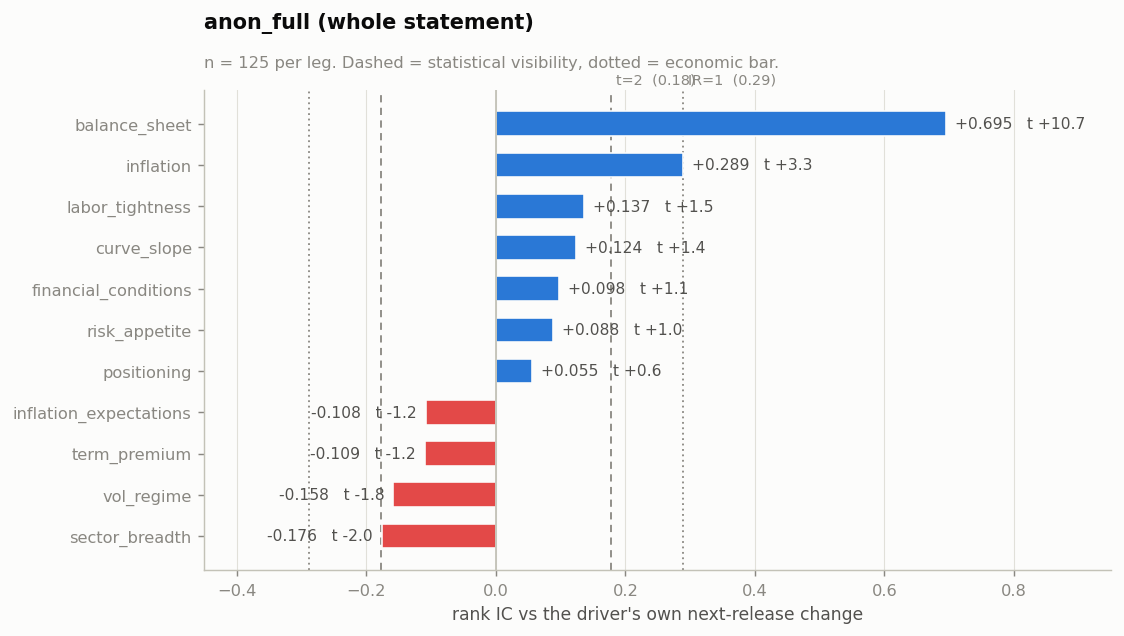

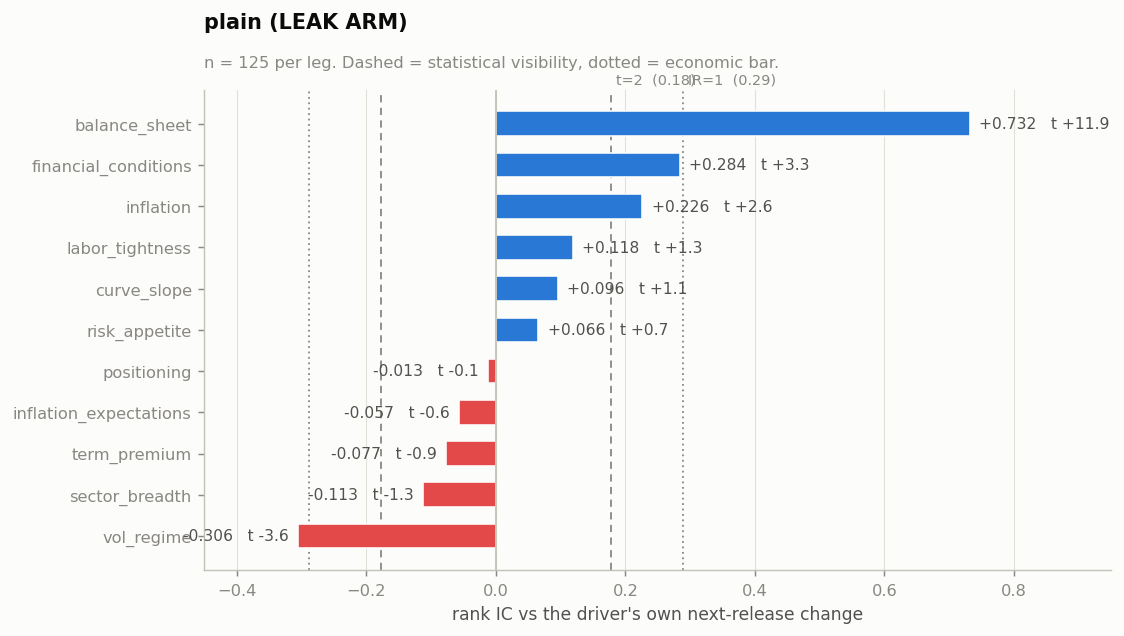

In [2]:
for arm in ARMS:
    d = IC[IC["arm"] == arm].sort_values("ic")
    n_med = int(d["n"].median())
    fig, ax = plt.subplots(figsize=(9.0, 4.8))
    y = np.arange(len(d))
    ax.barh(y, d["ic"], color=[V.POS if v >= 0 else V.NEG for v in d["ic"]],
            height=.6, zorder=3, edgecolor=V.SURFACE, linewidth=.9)
    ax.set_yticks(y); ax.set_yticklabels(d["driver"])
    for yi, (v, t_) in zip(y, zip(d["ic"], d["t"])):
        ax.text(v + (.014 if v >= 0 else -.014), yi, f"{v:+.3f}   t {t_:+.1f}",
                va="center", ha="left" if v >= 0 else "right", fontsize=8.6, color=V.INK2)
    for x, lab, ls in ((D.ic_for_t(2, n_med), f"t=2  ({D.ic_for_t(2,n_med):.2f})", (0,(4,3))),
                       (D.IR1_BAR, f"IR=1  ({D.IR1_BAR:.2f})", (0,(1,2)))):
        for sgn in (1, -1): ax.axvline(sgn*x, color=V.MUTED, lw=1.0, ls=ls, zorder=2)
        ax.annotate(lab, xy=(x, 1.0), xycoords=("data","axes fraction"), xytext=(3,3),
                    textcoords="offset points", fontsize=8, color=V.MUTED, annotation_clip=False)
    ax.axvline(0, color=V.AXIS, lw=1.0, zorder=4)
    ax.set_xlim(-.45, .95); ax.set_xlabel("rank IC vs the driver's own next-release change")
    V.title(ax, f"{LABEL[arm].replace(chr(10),' ')}",
            f"n = {n_med} per leg. Dashed = statistical visibility, dotted = economic bar.")
    V.grid(ax, "x"); plt.show()

## 2 — Does the view reach a tradeable yield?

The primary IC grades an analyst on **its own driver** — did inflation actually rise? That is
the claim it was asked to make, and it says nothing about whether the claim reaches a market.

Here the same signed conviction is scored against the forward change in four instrument
yields. **No driver→instrument map is declared**, deliberately: reporting every cell turns
the pods' polarity table into a falsifiable prediction about which cells should light up, and
a significant cell nobody predicted is more interesting than a confirmation.

Sign is `trade_pnl`'s: positive means a long view preceded the yield **rising**. Not a bond
return.

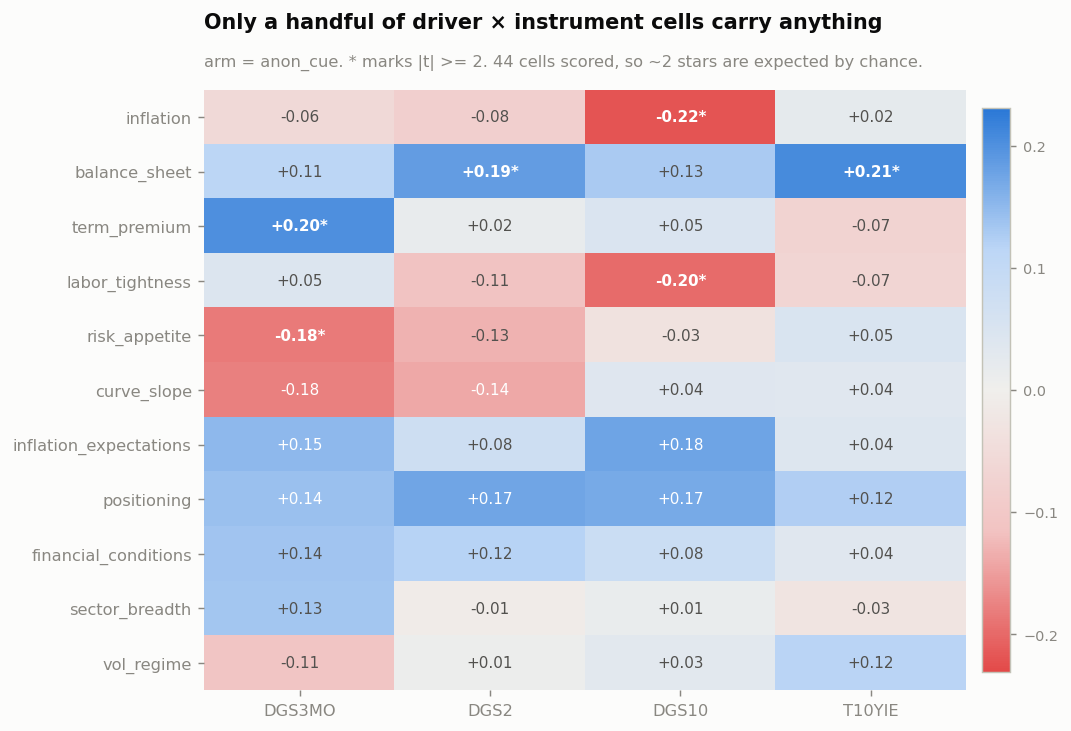

In [3]:
INSTR = ["DGS3MO", "DGS2", "DGS10", "T10YIE"]
macro = load_any_bundle(INSTR)

def inst_ic(arm):
    out = {}
    for d in DRIVERS:
        s = runs[(d, arm)].signed.dropna()
        if s.empty: continue
        fwd = forward_yield_change(macro, INSTR, pd.DatetimeIndex(s.index), steps=1,
                                   freq="B" if d in RELEASE else "ME")
        out[d] = {i: D.rank_ic(s, fwd[i])[1] for i in INSTR}
        out[d].update({f"t_{i}": D.rank_ic(s, fwd[i])[2] for i in INSTR})
    return pd.DataFrame(out).T

M = inst_ic(ARM)
vals, ts = M[INSTR], M[[f"t_{i}" for i in INSTR]]
order = vals.abs().max(axis=1).sort_values(ascending=False).index
vals, ts = vals.loc[order], ts.loc[order]
lim = float(vals.abs().max().max()) * 1.05

fig, ax = plt.subplots(figsize=(8.0, 6.0))
im = ax.imshow(vals.values, cmap=V.DIV, vmin=-lim, vmax=lim, aspect="auto")
ax.set_xticks(range(len(INSTR))); ax.set_xticklabels(INSTR)
ax.set_yticks(range(len(vals))); ax.set_yticklabels(vals.index)
for i in range(vals.shape[0]):
    for j in range(vals.shape[1]):
        v, t_ = vals.values[i, j], ts.values[i, j]
        ax.text(j, i, f"{v:+.2f}" + ("*" if abs(t_) >= 2 else ""), ha="center", va="center",
                fontsize=8.4, color="white" if abs(v) > lim*.6 else V.INK2,
                fontweight="600" if abs(t_) >= 2 else "normal")
for sp in ax.spines.values(): sp.set_visible(False)
cb = fig.colorbar(im, ax=ax, pad=.02, fraction=.035); cb.ax.tick_params(labelsize=8)
V.title(ax, "Only a handful of driver × instrument cells carry anything",
        f"arm = {ARM}. * marks |t| >= 2. {vals.size} cells scored, so ~{vals.size*0.05:.0f} "
        f"stars are expected by chance.")
plt.show()

## 2b — Predictability, premium, and whether driver skill reaches an asset

This is the section that reorders the board, and the argument is economic before it is
statistical.

The Fed's balance sheet is a **structural, administered series**. During QE it grows every
month; during QT it shrinks every month; the direction is announced in advance. It is
therefore highly predictable — and a highly predictable quantity carries **little uncertainty,
so little risk premium.** Being right about it earns nothing, because everyone else is right
about it too and the price already reflects that.

So the prediction is not that the analyst lacks skill. It plainly has skill at the task it was
set. The prediction is that **this particular skill should not reach a tradeable asset** — and
that is precisely what scoring against the instrument space, rather than against the driver's
own series, is for.

Generalised: **outcome autocorrelation is an ex-ante screen for a low-premium target.** It can
be computed before a single call is made, and it says which drivers will flatter an analyst.

In [4]:
from src.layered.evaluation.trade_pnl import forward_yield_change
INSTR4 = ["DGS3MO", "DGS2", "DGS10", "T10YIE"]
mac = load_any_bundle(INSTR4)

rows = []
for d in DRIVERS:
    r = runs[(d, ARM)]; s_, l_ = r.signed.dropna(), r.level.dropna()
    al = D.align(s_, l_); n, ic, t = D.rank_ic(al["s"], al["y"])
    fwd = forward_yield_change(mac, INSTR4, pd.DatetimeIndex(s_.index), steps=1,
                               freq="B" if d in RELEASE else "ME")
    # Mean across ALL four instruments, not the best of four: picking the max would
    # be a post-hoc selection over four correlated tries and biases the level upward.
    ics = [abs(D.rank_ic(s_, fwd[i])[1]) for i in INSTR4]
    rows.append({"driver": d, "ac1": al["y"].autocorr(1), "abs_driver_ic": abs(ic),
                 "mean_instr_ic": float(np.mean(ics)), "max_instr_ic": float(np.max(ics))})
TR = pd.DataFrame(rows).sort_values("ac1", ascending=False)
TR["transport"] = TR["mean_instr_ic"] / TR["abs_driver_ic"]

sp = lambda a, b: TR[a].corr(TR[b], method="spearman")
print(f"driver      |IC|  sd {TR['abs_driver_ic'].std():.3f}   "
      f"range {TR['abs_driver_ic'].min():.3f}-{TR['abs_driver_ic'].max():.3f}")
print(f"mean instr  |IC|  sd {TR['mean_instr_ic'].std():.3f}   "
      f"range {TR['mean_instr_ic'].min():.3f}-{TR['mean_instr_ic'].max():.3f}")
print(f"dispersion compression: {TR['abs_driver_ic'].std()/TR['mean_instr_ic'].std():.1f}x\n")
print(f"ac1 vs |driver IC|       spearman {sp('ac1','abs_driver_ic'):+.3f}   <- predictability buys driver IC")
print(f"ac1 vs mean |instr IC|   spearman {sp('ac1','mean_instr_ic'):+.3f}   <- and buys nothing in asset space")
print(f"ac1 vs transport ratio   spearman {sp('ac1','transport'):+.3f}   (fragile, see below)")
sub = TR[TR["abs_driver_ic"] >= .15]
print(f"   ... restricted to |driver IC|>=0.15 (n={len(sub)}): "
      f"{sub['ac1'].corr(sub['transport'], method='spearman'):+.3f}  -- does NOT hold up")
display(TR.round(3))

driver      |IC|  sd 0.172   range 0.043-0.655
mean instr  |IC|  sd 0.033   range 0.047-0.159
dispersion compression: 5.3x

ac1 vs |driver IC|       spearman +0.727   <- predictability buys driver IC
ac1 vs mean |instr IC|   spearman +0.173   <- and buys nothing in asset space
ac1 vs transport ratio   spearman -0.555   (fragile, see below)
   ... restricted to |driver IC|>=0.15 (n=6): -0.257  -- does NOT hold up


,driver,ac1,abs_driver_ic,mean_instr_ic,max_instr_ic,transport
0,balance_sheet,0.631,0.655,0.159,0.206,0.242
3,inflation,0.501,0.262,0.096,0.220,0.365
2,financial_conditions,0.308,0.198,0.093,0.136,0.469
1,curve_slope,0.162,0.282,0.098,0.178,0.346
7,risk_appetite,0.105,0.147,0.099,0.183,0.677
9,term_premium,0.071,0.049,0.085,0.201,1.755
5,labor_tightness,0.010,0.153,0.106,0.198,0.692
4,inflation_expectations,-0.017,0.043,0.111,0.176,2.551
8,sector_breadth,-0.139,0.161,0.047,0.134,0.291
10,vol_regime,-0.246,0.100,0.065,0.116,0.657


### The dispersion collapse

The slope chart is the whole argument in one figure. Left column is each analyst's IC against
its own driver; right column is the same conviction scored against tradeable yields. Lines are
coloured by outcome autocorrelation, so the structural targets are the dark ones.

The driver-space column spans a factor of 15. The asset-space column fits inside a band of
0.11 — **every driver, regardless of how well it did in driver space.** Nothing reaches the
economic bar.

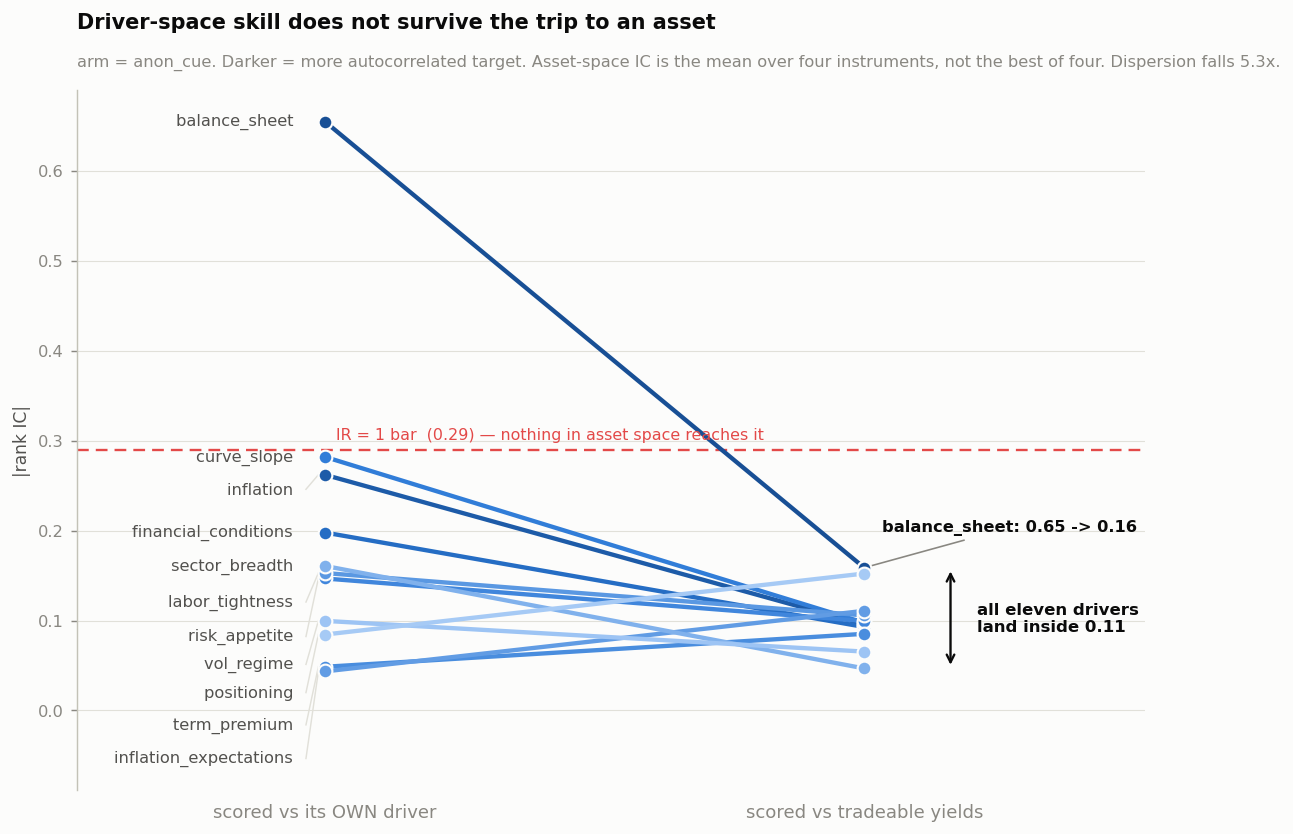

In [5]:
fig, ax = plt.subplots(figsize=(10.6, 7.0))
cols = V.seq_colors(TR["ac1"].values, floor=.30)
for (row, c) in zip(TR.itertuples(), cols):
    ax.plot([0, 1], [row.abs_driver_ic, row.mean_instr_ic], color=c, lw=2.4,
            zorder=3, solid_capstyle="round")
    ax.scatter([0, 1], [row.abs_driver_ic, row.mean_instr_ic], s=58, color=c,
               zorder=4, edgecolor=V.SURFACE, linewidth=1.2)

# Label the LEFT column only. Labelling both ends put six names on top of each other in
# the collapsed right column -- and the collapse is the point, so the labels there were
# fighting the message. Lines are traceable; the right column needs the band, not names.
GAP = (TR["abs_driver_ic"].max() - TR["abs_driver_ic"].min()) * 0.048
placed = []
for row, c in sorted(zip(TR.itertuples(), cols), key=lambda z: -z[0].abs_driver_ic):
    yy = row.abs_driver_ic
    while any(abs(yy - q) < GAP for q in placed):
        yy -= GAP * 0.55
    placed.append(yy)
    if abs(yy - row.abs_driver_ic) > GAP * 0.3:
        ax.plot([-0.035, -0.012], [yy, row.abs_driver_ic], color=V.GRID, lw=.8, zorder=2)
    ax.annotate(f"{row.driver}  ", (-0.04, yy), ha="right", va="center",
                fontsize=9.0, color=V.INK2)

ax.axhline(D.IR1_BAR, color=V.NEG, lw=1.3, ls=(0, (5, 3)), zorder=2)
ax.annotate(f"IR = 1 bar  ({D.IR1_BAR:.2f}) — nothing in asset space reaches it",
            xy=(.02, D.IR1_BAR), xytext=(0, 6), textcoords="offset points",
            ha="left", fontsize=8.8, color=V.NEG)
lo, hi = TR["mean_instr_ic"].min(), TR["mean_instr_ic"].max()
ax.annotate("", xy=(1.16, lo), xytext=(1.16, hi),
            arrowprops=dict(arrowstyle="<->", color=V.INK, lw=1.3))
ax.annotate(f"all eleven drivers\nland inside {hi-lo:.2f}", xy=(1.21, (lo+hi)/2),
            fontsize=9.2, color=V.INK, va="center", weight="600")
top = TR.nlargest(1, "abs_driver_ic").iloc[0]
ax.annotate(f"{top['driver']}: {top['abs_driver_ic']:.2f} -> {top['mean_instr_ic']:.2f}",
            (1, top["mean_instr_ic"]), xytext=(10, 20), textcoords="offset points",
            fontsize=9.0, color=V.INK, weight="600",
            arrowprops=dict(arrowstyle="-", color=V.MUTED, lw=.9))
ax.set_xlim(-.46, 1.52); ax.set_xticks([0, 1])
ax.set_xticklabels(["scored vs its OWN driver", "scored vs tradeable yields"], fontsize=10)
ax.set_ylabel("|rank IC|"); ax.spines["bottom"].set_visible(False)
ax.tick_params(bottom=False)
V.title(ax, "Driver-space skill does not survive the trip to an asset",
        f"arm = {ARM}. Darker = more autocorrelated target. Asset-space IC is the mean over "
        f"four instruments, not the best of four. Dispersion falls "
        f"{TR['abs_driver_ic'].std()/TR['mean_instr_ic'].std():.1f}x.")
V.grid(ax, "y"); plt.show()

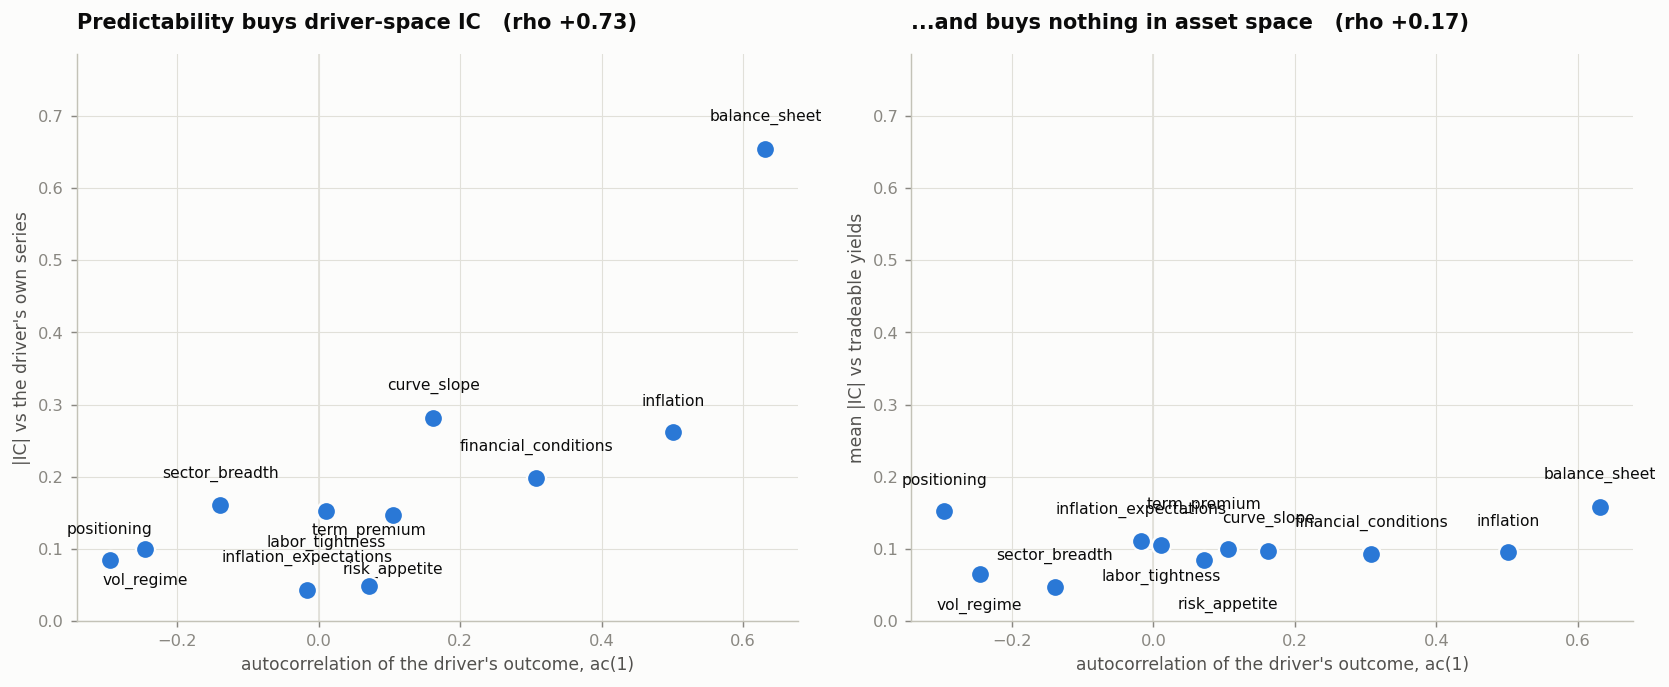

Same y-scale on both panels, deliberately: the flatness on the right is the finding,
and rescaling it to fill the axes would manufacture a slope that is not there.


In [6]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(13.0, 5.4), sharex=True)
for ax, col, lab, claim in (
        (a1, "abs_driver_ic", "|IC| vs the driver's own series",
         f"Predictability buys driver-space IC   (rho {sp('ac1','abs_driver_ic'):+.2f})"),
        (a2, "mean_instr_ic", "mean |IC| vs tradeable yields",
         f"...and buys nothing in asset space   (rho {sp('ac1','mean_instr_ic'):+.2f})")):
    ax.scatter(TR["ac1"], TR[col], s=112, color=V.POS, zorder=4,
               edgecolor=V.SURFACE, linewidth=1.3)
    V.repel(ax, TR["ac1"].values, TR[col].values, list(TR["driver"]))
    ax.axvline(0, color=V.GRID, lw=1.0, zorder=1)
    ax.set_xlabel("autocorrelation of the driver's outcome, ac(1)")
    ax.set_ylabel(lab)
    ax.set_ylim(0, max(TR["abs_driver_ic"].max(), TR["mean_instr_ic"].max()) * 1.20)
    V.title(ax, claim); V.grid(ax)
plt.tight_layout(); plt.show()
print("Same y-scale on both panels, deliberately: the flatness on the right is the finding,")
print("and rescaling it to fill the axes would manufacture a slope that is not there.")

### What this does and does not support

**Carries weight — no statistical test required.** The dispersion compression. Driver-space
|IC| ranges 0.043-0.655; asset-space mean |IC| ranges 0.047-0.159 for all eleven. A 15x spread
becomes a 0.11 band, and nothing clears 0.289.

**Carries weight.** ac(1) predicts driver-space IC (Spearman +0.73, n = 11) and does not
predict asset-space IC (+0.17). That *pair* is the result: predictability is rewarded in driver
space and unrewarded in asset space, which is what "no uncertainty, no premium" looks like when
you measure it rather than assert it.

**Does not carry weight, and is not claimed.** The transport ratio. Across all 11 drivers ac(1)
vs transport is -0.56, the direction the premium argument predicts — but restricted to the six
drivers with a non-trivial denominator it falls to -0.26. The full-sample figure leans on rows
where the denominator is near zero and the ratio explodes (`term_premium` 1.76,
`inflation_expectations` 2.55, `positioning` 1.80 are arithmetic, not findings). The two
results above do not depend on it.

**Also worth stating:** n = 11 drivers. These are cross-sectional correlations over eleven
points, which is enough to order the board and not enough to fit anything.

## 3 — The joint distribution behind one correlation

A rank IC of +0.30 and one of −0.30 can come from very different pictures. Outliers are
flagged the standard way: **studentized residuals** from the OLS fit, using the leave-one-out
sigma so a point cannot mask itself, at |t| > 2.5, labelled with their date. Marker size is
**Cook's distance**, which separates a high-leverage extreme call that was wrong from an
ordinary call that a freak move blindsided — different explanations, different repairs.

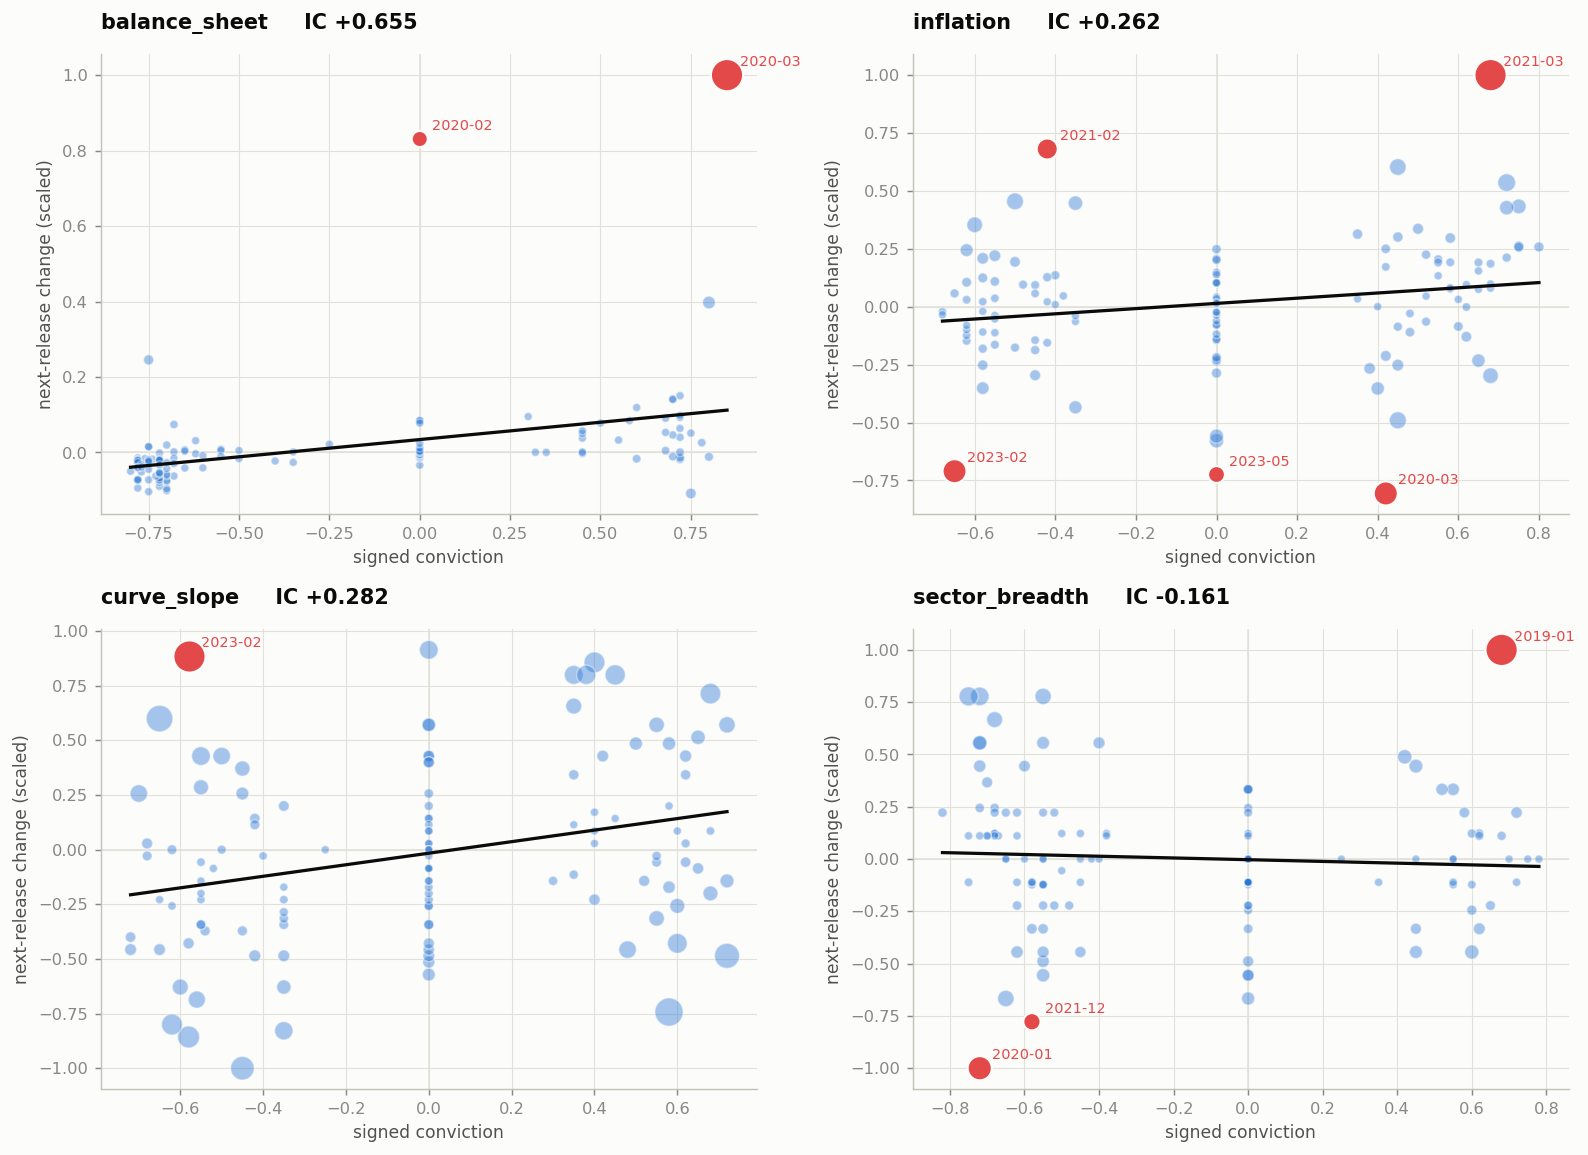

98 flagged observations across 44 legs. Most influential quarters:

q
2020Q1    47
2022Q3    11
2020Q2     6
2021Q1     6
2023Q1     5
2019Q1     4


In [7]:
show = ["balance_sheet", "inflation", "curve_slope", "sector_breadth"]
fig, axes = plt.subplots(2, 2, figsize=(12.4, 9.0))
for ax, drv in zip(axes.ravel(), show):
    r = runs[(drv, ARM)]
    o = D.ic_outliers(r.signed.dropna(), r.level.dropna(), z=2.5)
    norm = o["outcome"].abs().max() or 1.0
    yy, fit = o["outcome"]/norm, o["fitted"]/norm
    sz = 20 + 300*(o["cooks_d"]/max(1e-9, o["cooks_d"].max()))
    ok = ~o["is_outlier"]
    ax.scatter(o.loc[ok,"signed"], yy[ok], s=sz[ok], color=V.POS, alpha=.42,
               edgecolor=V.SURFACE, linewidth=.8, zorder=3)
    ax.scatter(o.loc[~ok,"signed"], yy[~ok], s=sz[~ok], color=V.NEG,
               edgecolor=V.SURFACE, linewidth=1.2, zorder=4)
    srt = o.sort_values("signed")
    ax.plot(srt["signed"], srt["fitted"]/norm, color=V.INK, lw=1.8, zorder=5)
    for dt, row in o[o["is_outlier"]].iterrows():
        ax.annotate(pd.Timestamp(dt).strftime("%Y-%m"), (row["signed"], row["outcome"]/norm),
                    textcoords="offset points", xytext=(7,5), fontsize=8, color=V.NEG)
    ax.axhline(0, color=V.GRID, lw=.9); ax.axvline(0, color=V.GRID, lw=.9)
    ic = IC[(IC.driver==drv)&(IC.arm==ARM)]["ic"].iloc[0]
    V.title(ax, f"{drv}     IC {ic:+.3f}")
    ax.set_xlabel("signed conviction"); ax.set_ylabel("next-release change (scaled)")
    V.grid(ax)
plt.tight_layout(); plt.show()

ALLOUT = pd.concat([D.ic_outliers(runs[(d,a)].signed.dropna(), runs[(d,a)].level.dropna())
                    .assign(driver=d, arm=a).query("is_outlier") for d in DRIVERS for a in ARMS])
byq = (ALLOUT.reset_index().assign(q=lambda x: pd.to_datetime(x["index"]).dt.to_period("Q").astype(str))
       .groupby("q").size().sort_values(ascending=False).head(6))
print(f"{len(ALLOUT)} flagged observations across 44 legs. Most influential quarters:\n")
print(byq.rename("flags").to_string())

## 4 — Rolling IC

24-observation trailing window. The shaded band is the region where |IC| would not reach
t = 2 **at that window length** — about 0.39, far above the full-sample threshold — so read
the **shape and the sign persistence**, not whether a point clears a line.

A rolling *t* is the same information rescaled by a constant while inviting exactly that
misreading; `D.rolling_t` exists and its own docstring argues against using it.

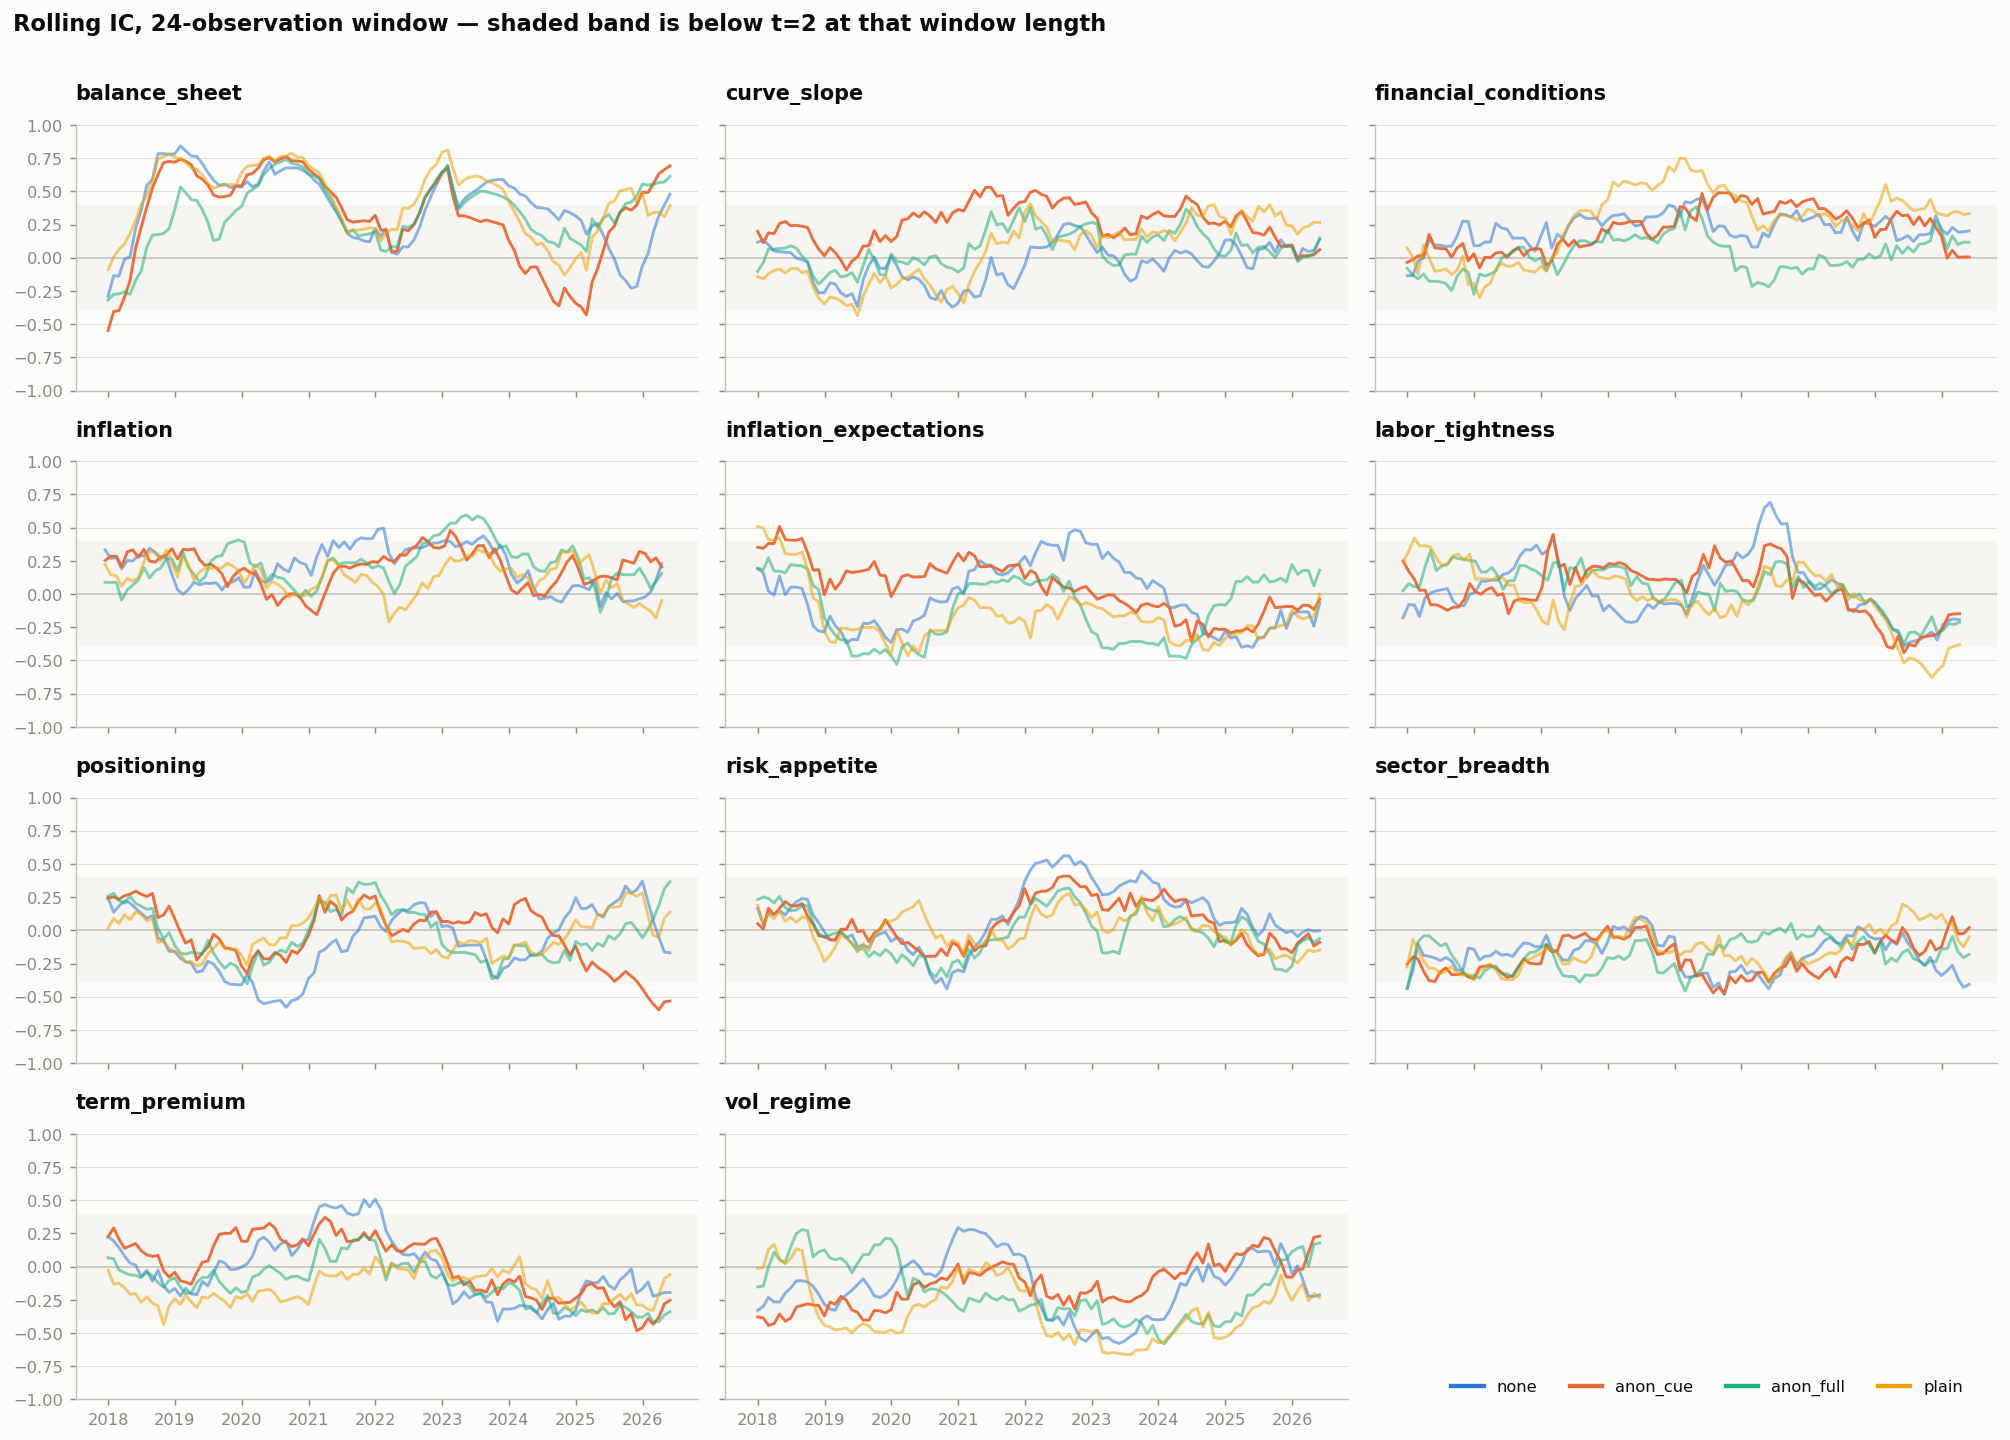

In [8]:
thr = D.ic_for_t(2, 24)
fig, axes = plt.subplots(4, 3, figsize=(15.5, 11.5), sharex=True, sharey=True)
for ax, drv in zip(axes.ravel(), DRIVERS):
    for i, arm in enumerate(ARMS):
        ric = D.rolling_ic(runs[(drv,arm)].signed.dropna(), runs[(drv,arm)].level.dropna(), 24)
        if ric.empty: continue
        ax.plot(ric.index, ric.values, color=V.CAT[i], lw=1.6, zorder=3,
                alpha=.95 if arm == ARM else .55)
    ax.axhspan(-thr, thr, color=V.BAND, zorder=1)
    ax.axhline(0, color=V.AXIS, lw=.9, zorder=2)
    ax.set_ylim(-1, 1); V.title(ax, drv); V.grid(ax, "y")
for ax in axes.ravel()[len(DRIVERS):]: ax.axis("off")
fig.legend(handles=[plt.Line2D([],[],color=V.CAT[i],lw=2.4,label=a.replace("\n"," "))
                    for i,a in enumerate(ARMS)],
           loc="lower right", bbox_to_anchor=(.98,.045), ncols=4)
fig.suptitle("Rolling IC, 24-observation window — shaded band is below t=2 at that window length",
             x=.005, ha="left", fontsize=12.5, color=V.INK, weight="600")
plt.tight_layout(rect=(0,.02,1,.975)); plt.show()

## 5 — Mean IC with margins: judging the analysts *and* the experiments

The row margin judges the **analyst** (mean across arms); the column margin judges the
**experiment** (mean across analysts). Different questions: a weak row is a weak analyst, a
weak column is an arm that helped nobody.

Two cells are not real comparisons. `positioning / anon_cue` is byte-identical to its `none`
arm, and the whole `plain` column is a leak probe — its mean is reported for completeness and
must not be read as "the best arm".

In [9]:
piv = IC.pivot_table(index="driver", columns="arm", values="ic")[ARMS]
tab = piv.copy(); tab["ANALYST"] = piv.mean(axis=1)
tab.loc["ARM MEAN"] = list(piv.mean(axis=0)) + [piv.values.mean()]
tab = tab.round(3)

def shade(v):
    if pd.isna(v): return ""
    a = min(1.0, abs(v)/.70)
    return f"background-color:{V.POS if v>=0 else V.NEG}{int(a*80+18):02x}"
display(tab.style.map(shade).format("{:+.3f}")
        .set_caption("mean rank IC — rows = analysts, columns = arms, margins = the two judgments"))

print("\nanalyst ranking, scoreable arms only (plain excluded as a leak probe):")
print(piv[["none","anon_cue","anon_full"]].mean(axis=1).sort_values(ascending=False)
      .round(3).to_string())
print("\narm ranking across all 11 analysts:")
print(piv.mean(axis=0).round(3).to_string())

arm,none,anon_cue,anon_full,plain,ANALYST
driver,,,,,
balance_sheet,+0.623,+0.655,+0.695,+0.732,+0.676
curve_slope,+0.050,+0.282,+0.124,+0.096,+0.138
financial_conditions,+0.244,+0.198,+0.098,+0.284,+0.206
inflation,+0.281,+0.262,+0.289,+0.226,+0.264
inflation_expectations,+0.010,+0.043,-0.108,-0.057,-0.028
labor_tightness,+0.074,+0.153,+0.137,+0.118,+0.121
positioning,-0.104,-0.084,+0.055,-0.013,-0.036
risk_appetite,+0.171,+0.147,+0.088,+0.066,+0.118
sector_breadth,-0.221,-0.161,-0.176,-0.113,-0.168



analyst ranking, scoreable arms only (plain excluded as a leak probe):
driver
balance_sheet             0.658
inflation                 0.277
financial_conditions      0.180
curve_slope               0.152
risk_appetite             0.136
labor_tightness           0.121
inflation_expectations   -0.018
term_premium             -0.035
positioning              -0.044
vol_regime               -0.138
sector_breadth           -0.186

arm ranking across all 11 analysts:
arm
none         0.084
anon_cue     0.131
anon_full    0.085
plain        0.087


## 6 — The t-statistic, and the five assumptions under it

`ic.py` computes

$$t = \mathrm{IC}\sqrt{\tfrac{n-2}{1-\mathrm{IC}^2}}$$

the classical test for a Pearson correlation applied to **ranks**, with a `p_approx` from
`math.erfc` — a **normal** approximation, not the t-distribution, because scipy is not a
dependency.

| # | assumption | the repo's defence | what still bites |
|---|---|---|---|
| 1 | observations independent | the release clock makes **outcome windows** non-overlapping | nothing about the **signal** side — a memory-armed analyst repeats itself, and a persistent driver has a persistent outcome |
| 2 | bivariate normality | — | ranks are uniform, so the transform is approximate at any *n* |
| 3 | normal tail for the p | fine at n≈125 | **wrong at n≈17**, exactly the post-2024 slice |
| 4 | no dominant observation | — | a correlation inherits one pair's leverage |
| 5 | a stable relationship | — | one number over 125 months assumes nothing changed |

Three antidotes need no distributional assumption at all: a **permutation** p, a
**bootstrap** interval, and a **jackknife**.

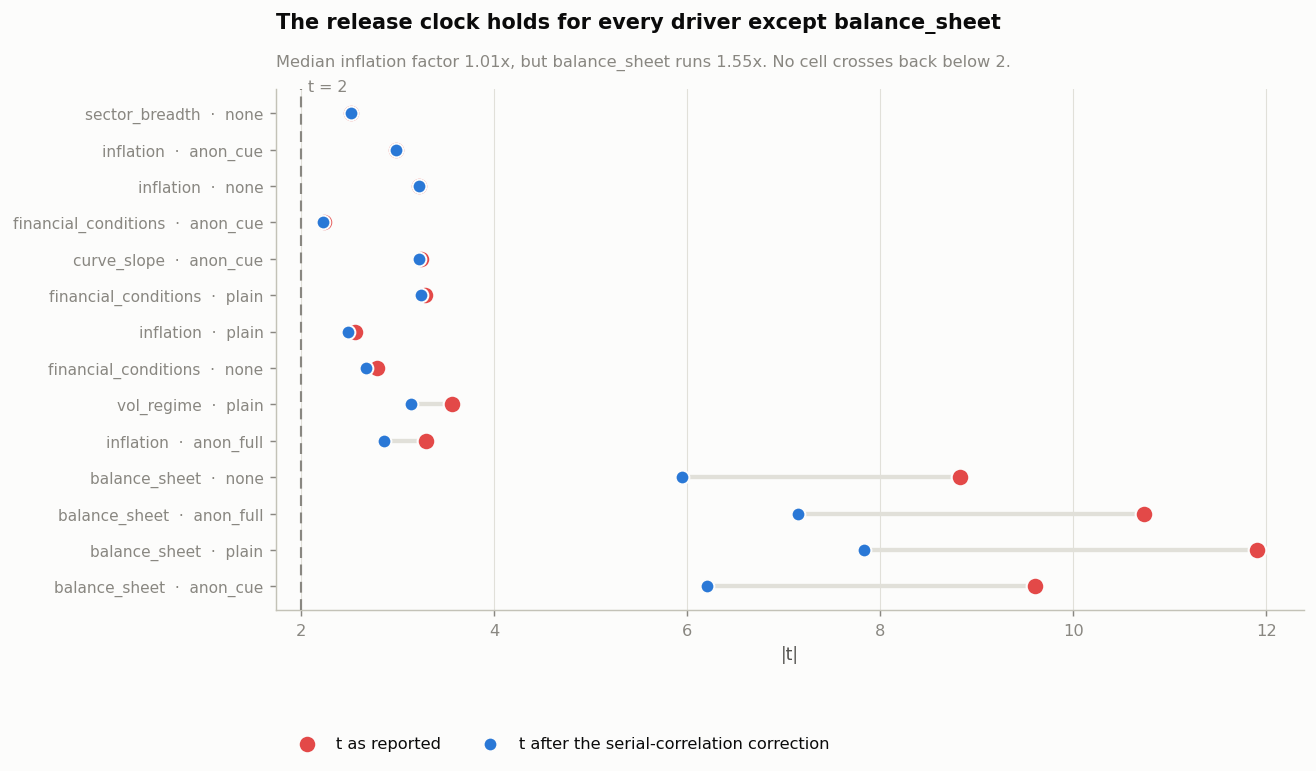

median n 125 -> n_eff 122  (98% of nominal)



,driver,arm,n,n_eff,r1_signal,t,t_adj,inflation_factor
1,balance_sheet,anon_cue,125,53.4,0.64,9.60,6.21,1.55
3,balance_sheet,plain,125,55.2,0.61,11.91,7.83,1.52
2,balance_sheet,anon_full,125,56.6,0.60,10.73,7.15,1.50
0,balance_sheet,none,125,57.8,0.58,8.83,5.95,1.48
14,inflation,anon_full,121,91.7,0.28,3.29,2.85,1.15
43,vol_regime,plain,125,97.5,-0.50,-3.56,-3.14,1.13



cells losing |t|>=2 after correction: 0  — no conclusion on this board depends on it


In [10]:
T = []
for d in DRIVERS:
    for a in ARMS:
        r = runs[(d,a)]; s, l = r.signed.dropna(), r.level.dropna()
        e, jk = D.effective_n(s, l), D.jackknife_t(s, l, drop=3)
        T.append({"driver":d,"arm":a,"n":e["n"],"ic":jk["ic"],"t":e["t"],
                  "r1_signal":e["r1_signal"],"n_eff":e["n_eff"],"t_adj":e["t_adj"],
                  "t_ex3":jk["t_ex"],"t_retained":jk["t_retained"],"dropped":", ".join(jk["dropped"])})
T = pd.DataFrame(T); T["inflation_factor"] = (T["t"].abs()/T["t_adj"].abs()).round(2)

sig = T[T["t"].abs() >= 2].sort_values("inflation_factor", ascending=False)
fig, ax = plt.subplots(figsize=(10.2, 5.2))
y = np.arange(len(sig))
ax.hlines(y, sig["t_adj"].abs(), sig["t"].abs(), color=V.GRID, lw=2.4, zorder=2)
ax.scatter(sig["t"].abs(), y, s=96, color=V.NEG, zorder=4, edgecolor=V.SURFACE,
           linewidth=1.2, label="t as reported")
ax.scatter(sig["t_adj"].abs(), y, s=58, color=V.POS, zorder=5, edgecolor=V.SURFACE,
           linewidth=1.1, label="t after the serial-correlation correction")
ax.axvline(2, color=V.MUTED, lw=1.2, ls=(0,(5,3)), zorder=3)
ax.annotate("t = 2", xy=(2, len(sig)-.4), xytext=(4,0), textcoords="offset points",
            fontsize=8.8, color=V.MUTED)
ax.set_yticks(y); ax.set_yticklabels([f"{r.driver}  ·  {r.arm}" for r in sig.itertuples()], fontsize=8.5)
ax.set_xlabel("|t|")
# Outside the axes: inside, it sat on top of the balance_sheet_plain marker.
ax.legend(loc="lower left", bbox_to_anchor=(0, -0.30), ncols=2)
worst = sig.iloc[0]
V.title(ax, "The release clock holds for every driver except balance_sheet",
        f"Median inflation factor {T['inflation_factor'].median():.2f}x, but "
        f"{worst['driver']} runs {worst['inflation_factor']:.2f}x. No cell crosses back below 2.")
V.grid(ax, "x"); plt.show()

print(f"median n {T['n'].median():.0f} -> n_eff {T['n_eff'].median():.0f}"
      f"  ({T['n_eff'].median()/T['n'].median()*100:.0f}% of nominal)\n")
display(T.nlargest(6,"inflation_factor")[["driver","arm","n","n_eff","r1_signal","t","t_adj","inflation_factor"]].round(2))
lost = T[(T['t'].abs()>=2) & (T['t_adj'].abs()<2)]
print(f"\ncells losing |t|>=2 after correction: {len(lost)}"
      + ("  — no conclusion on this board depends on it" if not len(lost) else ""))

In [11]:
print("assumptions 2 & 3 — does the parametric p survive an assumption-free test?\n")
chk=[]
for _, row in IC[IC["t"].abs() >= 2].iterrows():
    r = runs[(row["driver"], row["arm"])]
    pp = D.permutation_ic_pvalue(r.signed.dropna(), r.level.dropna(), n_perm=10_000)
    bs = D.bootstrap_ic_ci(r.signed.dropna(), r.level.dropna(), n_boot=5_000)
    chk.append({"driver":row["driver"],"arm":row["arm"],"ic":round(pp["ic"],3),
                "t":round(pp["t"],2),"p_approx":pp["p_approx"],"p_perm":pp["p_perm"],
                "boot_95":f"[{bs['lo']:+.2f}, {bs['hi']:+.2f}]",
                "ci_excludes_0":(bs["lo"]>0) or (bs["hi"]<0)})
CHK=pd.DataFrame(chk); display(CHK)
print(f"bootstrap CI excludes zero on {int(CHK['ci_excludes_0'].sum())}/{len(CHK)} cells.")
print("Where p_perm and p_approx agree the parametric t was fine; where they diverge, quote p_perm.")
print("\nassumption 4 — fragility. Drop the 3 highest-Cook's-D dates per leg:")
display(T[T['t'].abs()>=2].nsmallest(6,"t_retained")[["driver","arm","t","t_ex3","t_retained","dropped"]].round(2))
print("t_retained below ~0.7 would mean the result leans on those three months.")

assumptions 2 & 3 — does the parametric p survive an assumption-free test?



,driver,arm,ic,t,p_approx,p_perm,boot_95,ci_excludes_0
0,balance_sheet,anon_cue,0.655,9.60,7.733490e-22,0.0000,"[+0.52, +0.76]",True
1,balance_sheet,anon_full,0.695,10.73,7.233169e-27,0.0000,"[+0.56, +0.80]",True
2,balance_sheet,none,0.623,8.83,1.047917e-18,0.0000,"[+0.49, +0.73]",True
3,balance_sheet,plain,0.732,11.91,1.109373e-32,0.0000,"[+0.62, +0.82]",True
4,curve_slope,anon_cue,0.282,3.25,1.173837e-03,0.0019,"[+0.10, +0.45]",True
5,financial_conditions,anon_cue,0.198,2.24,2.523218e-02,0.0263,"[+0.00, +0.38]",True
6,financial_conditions,none,0.244,2.79,5.280849e-03,0.0055,"[+0.06, +0.42]",True
7,financial_conditions,plain,0.284,3.29,1.013841e-03,0.0012,"[+0.10, +0.46]",True
8,inflation,anon_cue,0.262,2.99,2.825776e-03,0.0038,"[+0.08, +0.42]",True
9,inflation,anon_full,0.289,3.29,1.007792e-03,0.0007,"[+0.10, +0.46]",True


bootstrap CI excludes zero on 14/14 cells.
Where p_perm and p_approx agree the parametric t was fine; where they diverge, quote p_perm.

assumption 4 — fragility. Drop the 3 highest-Cook's-D dates per leg:


,driver,arm,t,t_ex3,t_retained,dropped
14,inflation,anon_full,3.29,2.69,0.82,"2021-03-15, 2023-05-15, 2023-02-15"
15,inflation,plain,2.56,2.09,0.82,"2021-03-15, 2020-03-15, 2023-05-15"
12,inflation,none,3.22,2.68,0.83,"2021-03-15, 2020-03-15, 2023-05-15"
13,inflation,anon_cue,2.99,2.67,0.89,"2021-03-15, 2020-03-15, 2023-02-15"
1,balance_sheet,anon_cue,9.60,9.07,0.94,"2020-03-31, 2020-02-29, 2020-04-30"
9,financial_conditions,anon_cue,2.24,2.11,0.94,"2020-02-29, 2020-04-30, 2020-01-31"


t_retained below ~0.7 would mean the result leans on those three months.


## Caveats that travel with every number here

- **Never pool an arm delta across drivers.** Excerpt coverage runs from 0% (`positioning`)
  to 100% (`inflation`), so a pooled arm effect mostly reports which drivers got text.
- **`positioning`'s `anon_cue` is its `none` arm** — zero excerpt coverage by design.
- **`financial_conditions` cue coverage is 56%**, so a null there is part artifact.
- **`anon_cue` has no diff structure** and is not comparable to the pre-2026 `cue` legs.
- **`plain` is a leak probe.** Its IC never belongs in an analyst results table.
- **44 IC cells and 55 correlation pairs** were scored; expect ~2 and ~3 at |t|≥2 by chance.
- **The post-2024 slice is ~17 observations.** Sign agreement and hit rate only — no
  t-statistic, and `p_approx` is invalid at that n.
- **`curve_slope` and `risk_appetite` are graded on the same series** (outcome correlation
  +0.95). Their *calls* correlate only +0.29 — a catalogue defect, not a convergence finding.